In [2]:
import os
graphviz_path = r"c:\\Program Files\\Graphviz\bin"

# 将路径添加到系统的 PATH 环境变量中
os.environ["PATH"] += os.pathsep + graphviz_path

In [ ]:
# the value unit
class Value:
    # `label`用来表示流图上的节点名字
    # `grad` 代表参与计算的公式中作用于最终结果的梯度(全局梯度)
    def __init__(self, data, children = (), _op="", label =""):
        self.data = data
        self._prev = set(children)
        self._op = _op
        self.label = label
        self.grad = 0.0
    # print format    
    def __repr__(self):
        return f"Value(data={self.data})"
    
    # 重载操作符, 在对应运算时时将值的来源的记录下来
    def __add__(self, rhs):
        return Value(self.data + rhs.data, (self, rhs), "+")
    def __mul__(self, rhs):
        return Value(self.data * rhs.data, (self, rhs), "*")
        

In [4]:
from graphviz import Digraph

def trace(root:Value):
    nodes, edges = set[Value](), set()
    def build(v:Value):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root:Value):
    dot = Digraph(format="svg", graph_attr={"rankdir":"LR"})
    nodes, edges = trace(root)
    for node in nodes:
        uid  = str(id(node))
        dot.node(name= uid, label=f"{node.label} | data {node.data:.4f} | grad {node.grad:.4f}", shape="record")
        if node._op:
            dot.node(name =  uid + node._op, label = node._op)
            dot.edge(uid + node._op, uid)
            
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))+n2._op)
    return dot
    


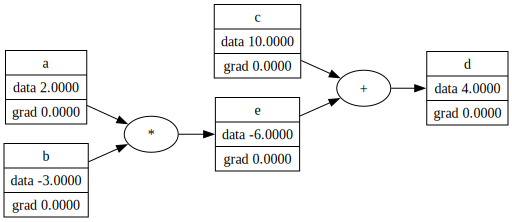

In [5]:
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0 , label="c")
d = a * b +c

d 
d._prev
d._op

e = a* b
e.label = "e"

d = e + c; d.label ="d"
draw_dot(d)

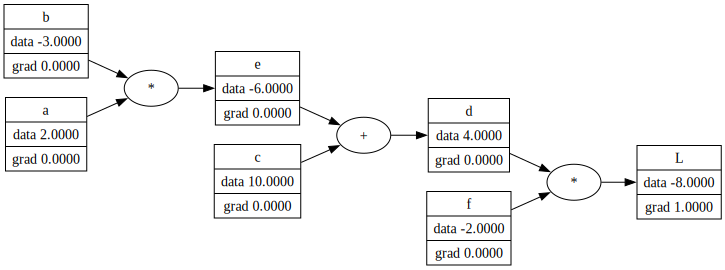

In [ ]:
# introducing a computation process : L = ((a*b) + c)*f
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0 , label="c")
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'

f = Value(-2.0, label="f")
L = d * f; L.label = 'L'
L.grad = 1
draw_dot(L)

In [ ]:
# mul case: the L = d * f, dL/dd = f, d    

# to prove, make the baseline value L1 & delta value applied on the specific that leads to L2
# based on (f(x+h)-f(x))/h
def get_grad(i):
    delta = 0.001
    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0 , label="c")
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'

    f = Value(-2.0, label="f")
    L = d * f; L.label = 'L'
    L1 = L.data
    
    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    if i == 'b':    
        b.data +=delta
    elif i == 'a':    
        a.data +=delta
    c = Value(10.0 , label="c")
    if i == 'c':    
        c.data +=delta
    e = a * b; e.label = 'e'
    if i == 'e':    
        e.data +=delta
    d = e + c; d.label = 'd'
    f = Value(-2.0, label="f")
    if i == 'd':
        d.data +=delta
    elif i == 'f':    
        f.data +=delta
 
    L = d * f; L.label = 'L'
    L2 = L.data
    
    print((L2-L1)/delta)

# compute the gradient of 'd' ,which is '-2', the value of 'f'
get_grad('d') 
# compute the gradient of 'f' whichi is 4, the value of 'd'
get_grad('f') 

-2.000000000000668
3.9999999999995595


In [19]:
# dd/dc = dd/de  = 1.0  ?  as the add case:  d = e + c  => dd/dc = 1.0 (we call local gradient)
# as L = f * (e + c) => dL/dc = dL/dd * dd/dc  => f * 1.0 = f
# c.grad = -2.0
# e.grad = -2.0
get_grad('c') 
get_grad('e') 

-1.9999999999988916
-2.000000000000668


In [20]:
# dL/de = -2.0
# dL / da = (dL / de) * (de / da)
# as e = a * b => de/da = b, de/db = a
# a.grad = dL /da  = -2.0 *b = 6.0
# b.grad = dL / db = -2.0 * a = -4.0
get_grad('a') 
get_grad('b') 

6.000000000000227
-3.9999999999995595


In [ ]:
# 梯度优化, 
def mini_optimization():
    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0 , label="c")
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label="f")